In [1]:
#!pip install --upgrade scikit-learn imbalanced-learn

In [2]:
#!pip install pandas numpy matplotlib seaborn xgboost catboost lightgbm scikit-learn

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


# Configuration
pd.set_option('display.max_columns', None)
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
tcga_df = pd.read_csv('dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('dataset/weseq_processed_with_id_and_race_V2.csv')

In [6]:
tcga_df

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,1,1,77.89,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
835,1,0,85.18,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
836,1,1,77.49,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
837,1,0,63.33,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0


In [7]:
cgga_df

,CGGA_ID,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,CGGA_528,0,1,51,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,CGGA_579,0,1,42,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,CGGA_653,0,0,33,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,CGGA_715,0,0,43,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,CGGA_723,0,1,25,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,CGGA_P87,1,0,32,2,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,1
282,CGGA_P89,1,0,42,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
283,CGGA_P90,1,1,52,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
284,CGGA_P95,0,1,44,2,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0


In [8]:
if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop('CGGA_ID', axis=1)
print('TCGA values\n',tcga_df.count())
print('CGGA values\n',cgga_df.count())

TCGA values
 Grade               839
Gender              839
Age_at_diagnosis    839
Race                839
IDH1                839
TP53                839
ATRX                839
PTEN                839
EGFR                839
CIC                 839
MUC16               839
PIK3CA              839
NF1                 839
PIK3R1              839
FUBP1               839
RB1                 839
NOTCH1              839
BCOR                839
CSMD3               839
SMARCA4             839
GRIN2A              839
IDH2                839
FAT4                839
PDGFRA              839
dtype: int64
CGGA values
 Grade               286
Gender              286
Age_at_diagnosis    286
Race                286
IDH1                286
TP53                286
ATRX                286
PTEN                286
EGFR                286
CIC                 286
MUC16               286
PIK3CA              286
NF1                 286
PIK3R1              286
FUBP1               286
RB1                 286
N

In [9]:
tcgaClassRace = tcga_df.groupby("Race")

In [10]:
print(f'''white {len(tcgaClassRace.get_group(0))}\nblack or african american {len(tcgaClassRace.get_group(1))}\nasian {len(tcgaClassRace.get_group(2))}\namerican indian or alaska native {len(tcgaClassRace.get_group(3))}''')

white 765
black or african american 59
asian 14
american indian or alaska native 1


In [11]:
'''print('Dropping race to make it less biased on External Dataset')
if 'Race' in cgga_df.columns:
    cgga_df = cgga_df.drop('Race', axis=1)
if 'Race' in tcga_df.columns:
    tcga_df = tcga_df.drop('Race', axis=1)'''


"print('Dropping race to make it less biased on External Dataset')\nif 'Race' in cgga_df.columns:\n    cgga_df = cgga_df.drop('Race', axis=1)\nif 'Race' in tcga_df.columns:\n    tcga_df = tcga_df.drop('Race', axis=1)"

In [12]:
tcga_df.head(10)

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,1,33.21,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,1,35.19,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,1,44.65,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,1,33.96,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,87.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
tcga_df.tail(10)

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
829,1,0,58.05,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
830,1,0,61.31,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
831,1,0,66.30,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
832,1,0,64.12,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
833,1,0,56.31,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
834,1,1,77.89,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
835,1,0,85.18,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
836,1,1,77.49,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
837,1,0,63.33,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0
838,1,0,76.61,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
cgga_df.head(10)

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,1,51,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,42,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,33,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,43,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,25,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,1,38,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,45,2,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
7,0,1,40,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,43,2,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
9,0,0,31,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [15]:
cgga_df.tail(10)

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
276,1,1,46,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
277,0,1,40,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
278,0,1,28,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
279,0,1,40,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
280,0,1,34,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
281,1,0,32,2,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,1
282,1,0,42,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
283,1,1,52,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
284,0,1,44,2,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
285,1,0,52,2,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [16]:
tcgaClassGrade = tcga_df.groupby("Grade")
print('Glioma grade class information (0 = "LGG"; 1 = "GBM")')
gradeCount = tcga_df['Grade'].value_counts()
print(gradeCount)
print(f"Difference {len(tcgaClassGrade.get_group(0))-len(tcgaClassGrade.get_group(1))}")
print(tcga_df.nunique())

Glioma grade class information (0 = "LGG"; 1 = "GBM")
Grade
0    487
1    352
Name: count, dtype: int64
Difference 135
Grade                 2
Gender                2
Age_at_diagnosis    766
Race                  4
IDH1                  2
TP53                  2
ATRX                  2
PTEN                  2
EGFR                  2
CIC                   2
MUC16                 2
PIK3CA                2
NF1                   2
PIK3R1                2
FUBP1                 2
RB1                   2
NOTCH1                2
BCOR                  2
CSMD3                 2
SMARCA4               2
GRIN2A                2
IDH2                  2
FAT4                  2
PDGFRA                2
dtype: int64


In [17]:
print('LGG (WHO II/III) -> 0, GBM (WHO IV) -> 1 were converted when merged the clinical data and mutation.\nAlso Gender: Male -> 0, Female -> 1, Set to 2 (Asian) to match TCGA encoding for CGGA data(Dropped),\nNaN are classified as Wildtype -> 0, missense_variants,stop_gained as Mutant -> 1')

cggaClassGrade = cgga_df.groupby("Grade")
gradeCount = cgga_df['Grade'].value_counts()
print(gradeCount)
print(f"Difference {len(cggaClassGrade.get_group(0))-len(cggaClassGrade.get_group(1))}")
print(cgga_df.nunique())

LGG (WHO II/III) -> 0, GBM (WHO IV) -> 1 were converted when merged the clinical data and mutation.
Also Gender: Male -> 0, Female -> 1, Set to 2 (Asian) to match TCGA encoding for CGGA data(Dropped),
NaN are classified as Wildtype -> 0, missense_variants,stop_gained as Mutant -> 1
Grade
0    184
1    102
Name: count, dtype: int64
Difference 82
Grade                2
Gender               2
Age_at_diagnosis    56
Race                 1
IDH1                 2
TP53                 2
ATRX                 2
PTEN                 2
EGFR                 2
CIC                  2
MUC16                2
PIK3CA               2
NF1                  2
PIK3R1               2
FUBP1                2
RB1                  2
NOTCH1               2
BCOR                 2
CSMD3                2
SMARCA4              2
GRIN2A               2
IDH2                 2
FAT4                 2
PDGFRA               2
dtype: int64


In [18]:
maxage=tcga_df.Age_at_diagnosis.max()
minage=tcga_df.Age_at_diagnosis.min()
avgage = tcga_df.Age_at_diagnosis.mean()
print(f"TCGA min age {minage}, max age {maxage}, avg age {avgage}")

TCGA min age 14.42, max age 89.29, avg age 50.93541120381406


In [19]:
maxC_age=cgga_df.Age_at_diagnosis.max()
minC_age=cgga_df.Age_at_diagnosis.min()
avgC_age = cgga_df.Age_at_diagnosis.mean()
print(f"CGGA min age {minC_age}, max age {maxC_age}, avg age {avgC_age}")

CGGA min age 10, max age 76, avg age 41.96853146853147


In [20]:
common_cols = list(set(tcga_df.columns) & set(cgga_df.columns))

tcga_df1 = tcga_df[common_cols]
cgga_df1 = cgga_df[common_cols]

print(f"Original TCGA Count: {len(tcga_df1)} (Min Age: {tcga_df1['Age_at_diagnosis'].min()})")
print(f"Original CGGA Count: {len(cgga_df1)} (Min Age: {cgga_df1['Age_at_diagnosis'].min()})")

Original TCGA Count: 839 (Min Age: 14.42)
Original CGGA Count: 286 (Min Age: 10)


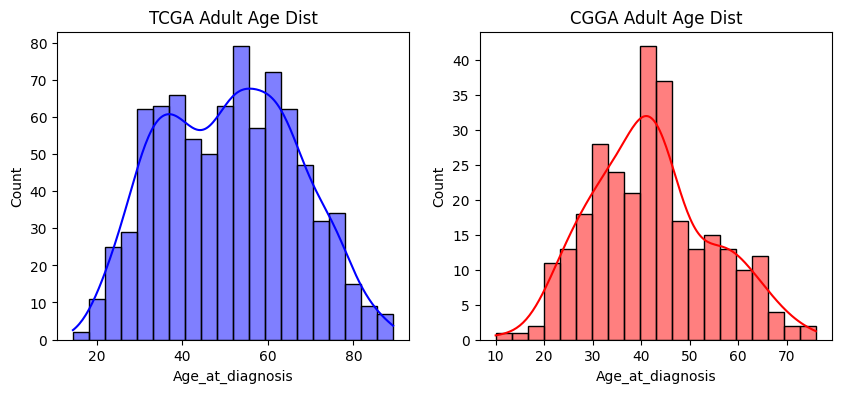

In [21]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(tcga_df['Age_at_diagnosis'], bins=20, color='blue', kde=True)
plt.title('TCGA Adult Age Dist')
plt.subplot(1, 2, 2)
sns.histplot(cgga_df['Age_at_diagnosis'], bins=20, color='red', kde=True)
plt.title('CGGA Adult Age Dist')
plt.show()

In [22]:
print("Z normalization")
print('TCGA')
mean_age = tcga_df['Age_at_diagnosis'].mean()
std_age = tcga_df['Age_at_diagnosis'].std()
z_scores = (tcga_df['Age_at_diagnosis'] - mean_age) / std_age
print(f'mean age: {mean_age} std age {std_age} \nZ score \n{z_scores}' )

print('CGGA')
Cmean_age = cgga_df['Age_at_diagnosis'].mean()
Cstd_age = cgga_df['Age_at_diagnosis'].std()
Cz_scores = (cgga_df['Age_at_diagnosis'] - Cmean_age) / Cstd_age
print(f'mean age: {Cmean_age} std age {Cstd_age} \nZ score \n{Cz_scores}' )

Z normalization
TCGA
mean age: 50.93541120381406 std age 15.70233865321824 
Z score 
0      0.023219
1     -0.777936
2     -1.004017
3     -1.156223
4     -1.237103
         ...   
834    1.716597
835    2.180859
836    1.691123
837    0.789347
838    1.635081
Name: Age_at_diagnosis, Length: 839, dtype: float64
CGGA
mean age: 41.96853146853147 std age 12.339171228562243 
Z score 
0      0.731935
1      0.002550
2     -0.726834
3      0.083593
4     -1.375176
         ...   
281   -0.807877
282    0.002550
283    0.812977
284    0.164636
285    0.812977
Name: Age_at_diagnosis, Length: 286, dtype: float64


In [23]:
print('TCGA')
outliers = tcga_df[np.abs(z_scores) > 3]

print(f"Mean Age: {mean_age:.2f}")
if len(outliers) == 0:
    print("RESULT: No statistical outliers detected.")
else:
    print(f"RESULT: {len(outliers)} statistical outliers detected (Age > 3 SDs from mean).")

print('CGGA')
C_outliers = cgga_df[np.abs(Cz_scores) > 3]

print(f"Mean Age: {Cmean_age:.2f}")
if len(C_outliers) == 0:
    print("RESULT: No statistical outliers detected.")
else:
    print(f"RESULT: {len(C_outliers)} statistical outliers detected (Age > 3 SDs from mean).")

TCGA
Mean Age: 50.94
RESULT: No statistical outliers detected.
CGGA
Mean Age: 41.97
RESULT: No statistical outliers detected.


In [24]:
scaler = MinMaxScaler()
scaler.fit(tcga_df[['Age_at_diagnosis']])
#transform TCGA
tcga_df['Age_at_diagnosis'] = scaler.transform(tcga_df[['Age_at_diagnosis']])
#transform CGGA
cgga_df['Age_at_diagnosis'] = scaler.transform(cgga_df[['Age_at_diagnosis']])

In [25]:
tcga_df.head(3)

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,0.492587,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,0.324563,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0.277147,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [26]:
cgga_df.head(3)

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,1,0.488580,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0.368372,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0.248163,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
#import models
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [28]:
# Data Preparation
X_tcga = tcga_df.drop('Grade', axis=1)
y_tcga = tcga_df['Grade']

X_cgga = cgga_df.drop('Grade', axis=1)
y_cgga = cgga_df['Grade']

In [29]:
# Split TCGA into 80% training, 20% testing (NO validation set)
X_train, X_test, y_train, y_test = train_test_split(
    X_tcga, y_tcga, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_tcga
)

In [30]:
print(f"Training set size: {len(X_train)} ({len(X_train)/len(X_tcga)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X_tcga)*100:.1f}%)")
print(f"External validation (CGGA) size: {len(X_cgga)}")

Training set size: 671 (80.0%)
Test set size: 168 (20.0%)
External validation (CGGA) size: 286


In [31]:
# Normalization
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_cgga_scaled = scaler.transform(X_cgga)

In [32]:
print(f"Class distribution in original training: {Counter(y_train)}")

Class distribution in original training: Counter({0: 389, 1: 282})


In [33]:
# Apply SMOTE to training data only 
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE - Training size: {len(X_train_balanced)}")
print(f"Class distribution after SMOTE: {Counter(y_train_balanced)}")

After SMOTE - Training size: 778
Class distribution after SMOTE: Counter({0: 389, 1: 389})


In [34]:
class ModelTrainer:
    def __init__(self, model, model_name):
        self.model = model
        self.model_name = model_name
        self.results = {}
        
    def train_with_cv(self, X, y, n_splits=10):
        """Train model with cross-validation"""
        print(f"\n{'='*60}")
        print(f"Training {self.model_name} with {n_splits}-fold CV")
        print('='*60)
        
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = []
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
            X_fold_train, X_fold_val = X[train_idx], X[val_idx]
            y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # Train on this fold
            self.model.fit(X_fold_train, y_fold_train)
            
            # Predict and evaluate
            y_pred = self.model.predict(X_fold_val)
            
            # Calculate metrics
            accuracy = accuracy_score(y_fold_val, y_pred)
            precision = precision_score(y_fold_val, y_pred, average='weighted')
            recall = recall_score(y_fold_val, y_pred, average='weighted')
            f1 = f1_score(y_fold_val, y_pred, average='weighted')
            
            cv_scores.append({
                'fold': fold + 1,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1
            })
            
            print(f"  Fold {fold + 1}: Accuracy = {accuracy:.4f}, F1 = {f1:.4f}")
        
        # Calculate average CV scores
        avg_scores = {
            'accuracy': np.mean([s['accuracy'] for s in cv_scores]),
            'precision': np.mean([s['precision'] for s in cv_scores]),
            'recall': np.mean([s['recall'] for s in cv_scores]),
            'f1': np.mean([s['f1'] for s in cv_scores])
        }
        
        self.results['cv_scores'] = cv_scores
        self.results['cv_avg'] = avg_scores
        
        print(f"\nCV Averages: Accuracy = {avg_scores['accuracy']:.4f}, "
              f"Precision = {avg_scores['precision']:.4f}, "
              f"Recall = {avg_scores['recall']:.4f}, "
              f"F1 = {avg_scores['f1']:.4f}")
        
        return avg_scores
    
    def train_final(self, X_train, y_train):
        """Train final model on entire training set"""
        print(f"\nTraining final {self.model_name} model...")
        self.model.fit(X_train, y_train)
        print("Training completed!")
    
    def evaluate(self, X_sets, y_sets, set_names):
        print(f"\nEvaluating {self.model_name}...")
        evaluation_results = {}
        
        for i, (X, y) in enumerate(zip(X_sets, y_sets)):
            set_name = set_names[i]
            y_pred = self.model.predict(X)
            
            accuracy = accuracy_score(y, y_pred)
            precision = precision_score(y, y_pred, average='weighted')
            recall = recall_score(y, y_pred, average='weighted')
            f1 = f1_score(y, y_pred, average='weighted')
            
            # ==========================================================
            # MODIFIED PART: ROC AUC Fallback Logic
            # ==========================================================
            roc_auc = None
            try:
                if hasattr(self.model, "predict_proba"):
                    # Use probabilities for Forest/Boost/LogReg models
                    y_score = self.model.predict_proba(X)[:, 1]
                elif hasattr(self.model, "decision_function"):
                    # Fallback to raw scores for RidgeClassifier
                    y_score = self.model.decision_function(X)
                else:
                    y_score = None

                if y_score is not None and len(np.unique(y)) > 1:
                    roc_auc = roc_auc_score(y, y_score)
            except Exception as e:
                print(f"      Note: Could not calculate ROC AUC for {self.model_name}: {e}")
            # ==========================================================
            
            cm = confusion_matrix(y, y_pred)
            evaluation_results[set_name] = {
                'accuracy': accuracy, 'precision': precision, 'recall': recall,
                'f1': f1, 'roc_auc': roc_auc, 'confusion_matrix': cm
            }
        self.results['evaluation'] = evaluation_results
        return evaluation_results
    
        """Evaluate model on multiple datasets"""
        print(f"\nEvaluating {self.model_name}...")
        
        evaluation_results = {}
        
        for i, (X, y) in enumerate(zip(X_sets, y_sets)):
            set_name = set_names[i]
            y_pred = self.model.predict(X)
            
            # Calculate metrics
            accuracy = accuracy_score(y, y_pred)
            precision = precision_score(y, y_pred, average='weighted')
            recall = recall_score(y, y_pred, average='weighted')
            f1 = f1_score(y, y_pred, average='weighted')
            
            # Try to calculate ROC AUC
            try:
                y_pred_proba = self.model.predict_proba(X)
                if len(np.unique(y)) > 1:
                    roc_auc = roc_auc_score(y, y_pred_proba[:, 1])
                else:
                    roc_auc = None
            except:
                roc_auc = None
            
            # Confusion matrix
            cm = confusion_matrix(y, y_pred)
            
            evaluation_results[set_name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'roc_auc': roc_auc,
                'confusion_matrix': cm
            }
            
            print(f"\n  {set_name} Set:")
            print(f"    Accuracy:  {accuracy:.4f}")
            print(f"    Precision: {precision:.4f}")
            print(f"    Recall:    {recall:.4f}")
            print(f"    F1-Score:  {f1:.4f}")
            if roc_auc:
                print(f"    ROC-AUC:   {roc_auc:.4f}")
        
        self.results['evaluation'] = evaluation_results
        return evaluation_results
    
    def plot_confusion_matrices(self):
        """Plot confusion matrices for all evaluated sets"""
        if 'evaluation' not in self.results:
            print("No evaluation results to plot!")
            return
        
        evaluation = self.results['evaluation']
        n_sets = len(evaluation)
        
        fig, axes = plt.subplots(1, n_sets, figsize=(5*n_sets, 4))
        if n_sets == 1:
            axes = [axes]
        
        for idx, (set_name, results) in enumerate(evaluation.items()):
            cm = results['confusion_matrix']
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
            axes[idx].set_title(f'{self.model_name}\n{set_name} Set')
            axes[idx].set_xlabel('Predicted')
            axes[idx].set_ylabel('Actual')
        
        plt.tight_layout()
        plt.show()
    
    def get_feature_importance(self, feature_names):
        """Get feature importance if the model supports it"""
        if hasattr(self.model, 'feature_importances_'):
            importances = self.model.feature_importances_
            indices = np.argsort(importances)[::-1]
            
            # Create DataFrame
            importance_df = pd.DataFrame({
                'feature': feature_names[indices],
                'importance': importances[indices]
            })
            
            # Plot top features
            plt.figure(figsize=(10, 6))
            top_n = min(15, len(feature_names))
            plt.barh(range(top_n), importance_df['importance'].values[:top_n][::-1])
            plt.yticks(range(top_n), importance_df['feature'].values[:top_n][::-1])
            plt.xlabel('Importance')
            plt.title(f'{self.model_name} - Top {top_n} Feature Importance')
            plt.tight_layout()
            plt.show()
            
            return importance_df
        else:
            print(f"{self.model_name} doesn't support feature importance analysis.")
            return None

In [35]:
# Define all models
models_dict = {
    'RandomForest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42,
        class_weight='balanced'
    ),
    'LogisticRegression': LogisticRegression(
        random_state=42, 
        max_iter=1000,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        random_state=42, 
        use_label_encoder=False, 
        eval_metric='logloss',
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=50,
        random_state=42
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ),
    'CatBoost': CatBoostClassifier(
        random_state=42, 
        verbose=0,
        auto_class_weights='Balanced'
    ),
    'LightGBM': LGBMClassifier(
        random_state=42, 
        verbose=-1,
        class_weight='balanced'
    ),
    'RidgeClassifier': RidgeClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    'Lasso_Logistic': LogisticRegression(
        penalty='l1',  # L1 regularization (Lasso)
        C=1.0,         # Inverse of regularization strength
        solver='saga', # Supports L1 penalty
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    )

}

In [36]:
# Create trainer objects for each model
trainers = {}
for name, model in models_dict.items():
    trainers[name] = ModelTrainer(model, name)

In [37]:
# TRAIN AND EVALUATE ALL MODELS
print("\n" + "="*80)
print("TRAINING AND EVALUATING ALL MODELS")
print("="*80)


TRAINING AND EVALUATING ALL MODELS



1. RANDOM FOREST CLASSIFIER

Training RandomForest with 10-fold CV
  Fold 1: Accuracy = 0.8205, F1 = 0.8205
  Fold 2: Accuracy = 0.8974, F1 = 0.8972
  Fold 3: Accuracy = 0.8718, F1 = 0.8718
  Fold 4: Accuracy = 0.8077, F1 = 0.8077
  Fold 5: Accuracy = 0.8205, F1 = 0.8204
  Fold 6: Accuracy = 0.8974, F1 = 0.8963
  Fold 7: Accuracy = 0.8846, F1 = 0.8846
  Fold 8: Accuracy = 0.9231, F1 = 0.9230
  Fold 9: Accuracy = 0.8701, F1 = 0.8695
  Fold 10: Accuracy = 0.8052, F1 = 0.8051

CV Averages: Accuracy = 0.8598, Precision = 0.8632, Recall = 0.8598, F1 = 0.8596

Training final RandomForest model...
Training completed!

Evaluating RandomForest...


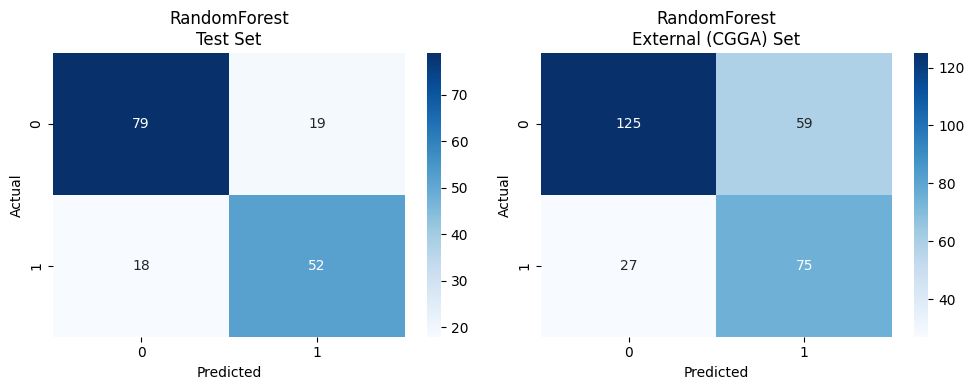

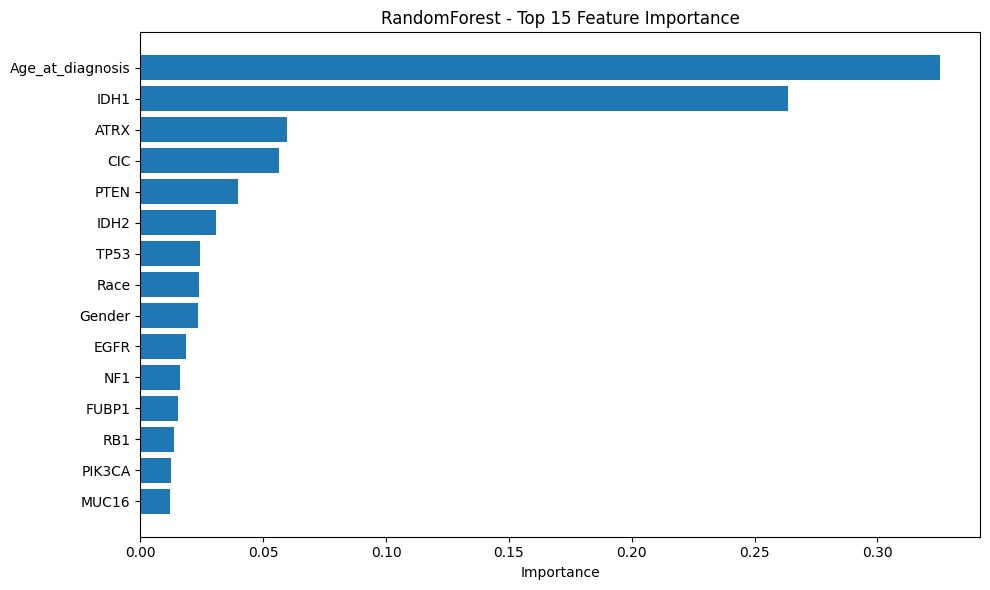

In [38]:
#RandomForest
print("\n" + "="*60)
print("1. RANDOM FOREST CLASSIFIER")
print("="*60)

rf_trainer = trainers['RandomForest']

# Cross-validation
rf_cv_results = rf_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
rf_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on all sets
# For RandomForest example:
rf_eval_results = rf_trainer.evaluate(
    X_sets=[X_test_scaled, X_cgga_scaled],  # Removed validation set
    y_sets=[y_test, y_cgga],
    set_names=['Test', 'External (CGGA)']   # Only two sets
)

# Similarly for all other models

# Plot confusion matrices
rf_trainer.plot_confusion_matrices()

# Feature importance
feature_names = X_tcga.columns
rf_importance = rf_trainer.get_feature_importance(feature_names)


2. XGBOOST CLASSIFIER

Training XGBoost with 10-fold CV
  Fold 1: Accuracy = 0.8205, F1 = 0.8204
  Fold 2: Accuracy = 0.8846, F1 = 0.8844
  Fold 3: Accuracy = 0.8718, F1 = 0.8718
  Fold 4: Accuracy = 0.8205, F1 = 0.8204
  Fold 5: Accuracy = 0.8462, F1 = 0.8457
  Fold 6: Accuracy = 0.8846, F1 = 0.8841
  Fold 7: Accuracy = 0.8590, F1 = 0.8590
  Fold 8: Accuracy = 0.9359, F1 = 0.9358
  Fold 9: Accuracy = 0.8961, F1 = 0.8961
  Fold 10: Accuracy = 0.7532, F1 = 0.7509

CV Averages: Accuracy = 0.8572, Precision = 0.8599, Recall = 0.8572, F1 = 0.8569

Training final XGBoost model...
Training completed!

Evaluating XGBoost...


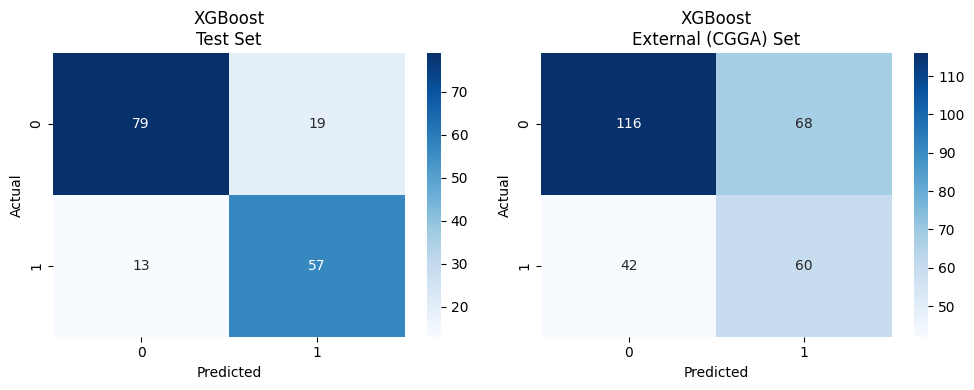

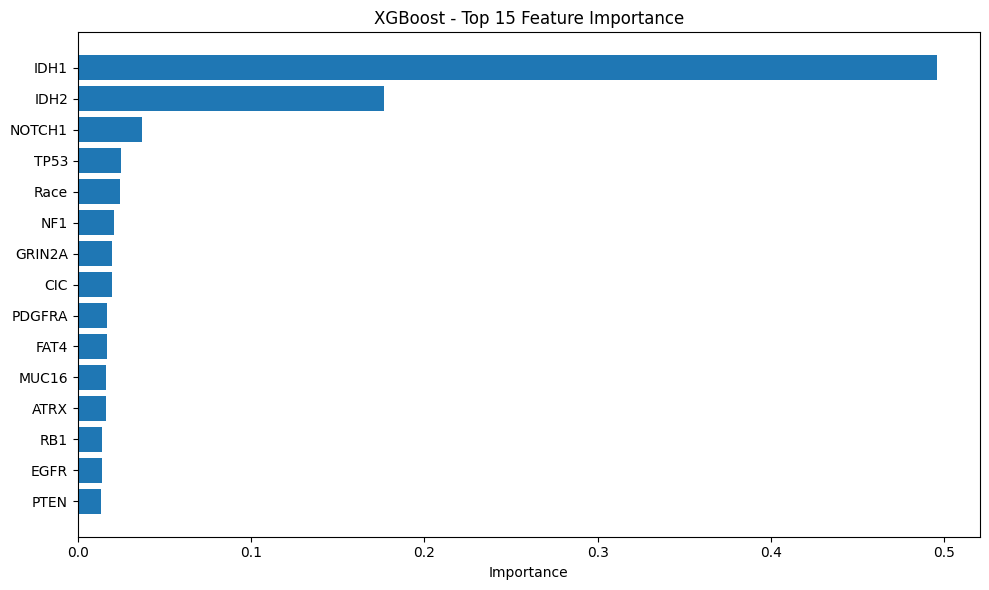

In [39]:
print("\n" + "="*60)
print("2. XGBOOST CLASSIFIER")
print("="*60)

xgb_trainer = trainers['XGBoost']

# Cross-validation
xgb_cv_results = xgb_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
xgb_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on all sets
xgb_eval_results = xgb_trainer.evaluate(
    X_sets=[X_test_scaled, X_cgga_scaled],
    y_sets=[y_test, y_cgga],
    set_names=['Test', 'External (CGGA)']
)

# Plot confusion matrices
xgb_trainer.plot_confusion_matrices()

# Feature importance
xgb_importance = xgb_trainer.get_feature_importance(feature_names)



3. LOGISTIC REGRESSION

Training LogisticRegression with 10-fold CV
  Fold 1: Accuracy = 0.8333, F1 = 0.8333
  Fold 2: Accuracy = 0.9487, F1 = 0.9487
  Fold 3: Accuracy = 0.8718, F1 = 0.8717
  Fold 4: Accuracy = 0.8333, F1 = 0.8331
  Fold 5: Accuracy = 0.8718, F1 = 0.8704
  Fold 6: Accuracy = 0.9103, F1 = 0.9095
  Fold 7: Accuracy = 0.8205, F1 = 0.8200
  Fold 8: Accuracy = 0.9615, F1 = 0.9615
  Fold 9: Accuracy = 0.9091, F1 = 0.9090
  Fold 10: Accuracy = 0.8052, F1 = 0.8042

CV Averages: Accuracy = 0.8766, Precision = 0.8814, Recall = 0.8766, F1 = 0.8761

Training final LogisticRegression model...
Training completed!

Evaluating LogisticRegression...


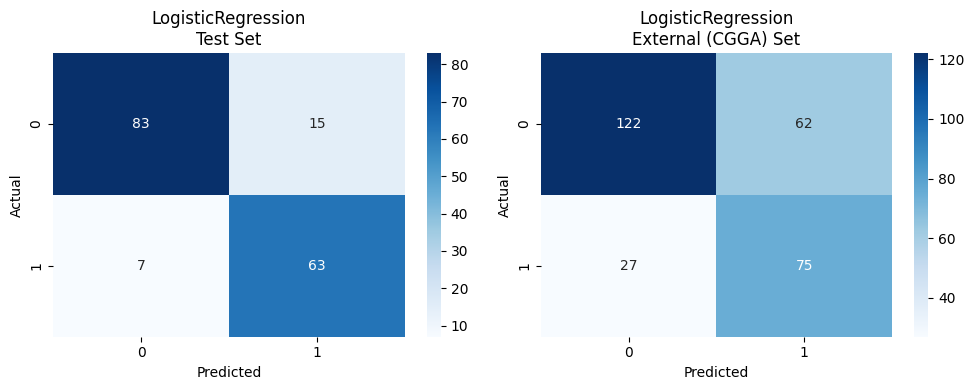

In [40]:

print("\n" + "="*60)
print("3. LOGISTIC REGRESSION")
print("="*60)

lr_trainer = trainers['LogisticRegression']

# Cross-validation
lr_cv_results = lr_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
lr_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on test and external sets
lr_eval_results = lr_trainer.evaluate(
    X_sets=[X_test_scaled, X_cgga_scaled],
    y_sets=[y_test, y_cgga],
    set_names=['Test', 'External (CGGA)']
)

# Plot confusion matrices
lr_trainer.plot_confusion_matrices()


4. ADABOOST CLASSIFIER

Training AdaBoost with 10-fold CV
  Fold 1: Accuracy = 0.8333, F1 = 0.8333
  Fold 2: Accuracy = 0.9487, F1 = 0.9487
  Fold 3: Accuracy = 0.8718, F1 = 0.8717
  Fold 4: Accuracy = 0.8590, F1 = 0.8588
  Fold 5: Accuracy = 0.8718, F1 = 0.8704
  Fold 6: Accuracy = 0.9103, F1 = 0.9095
  Fold 7: Accuracy = 0.8205, F1 = 0.8200
  Fold 8: Accuracy = 0.9487, F1 = 0.9487
  Fold 9: Accuracy = 0.9091, F1 = 0.9090
  Fold 10: Accuracy = 0.7922, F1 = 0.7907

CV Averages: Accuracy = 0.8765, Precision = 0.8814, Recall = 0.8765, F1 = 0.8761

Training final AdaBoost model...
Training completed!

Evaluating AdaBoost...


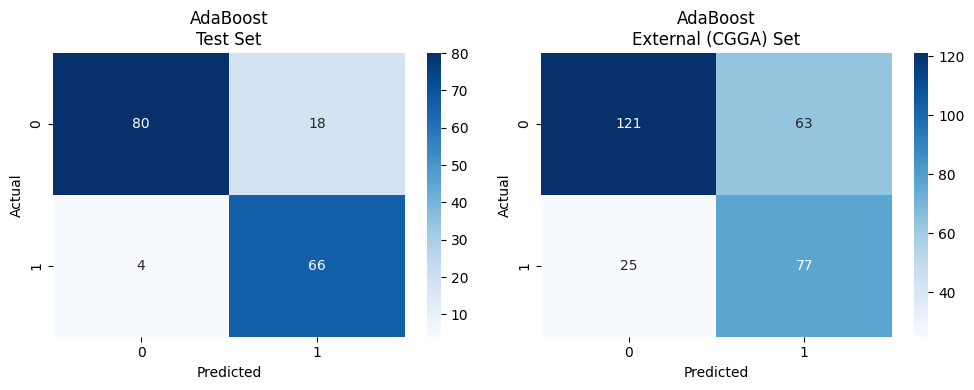

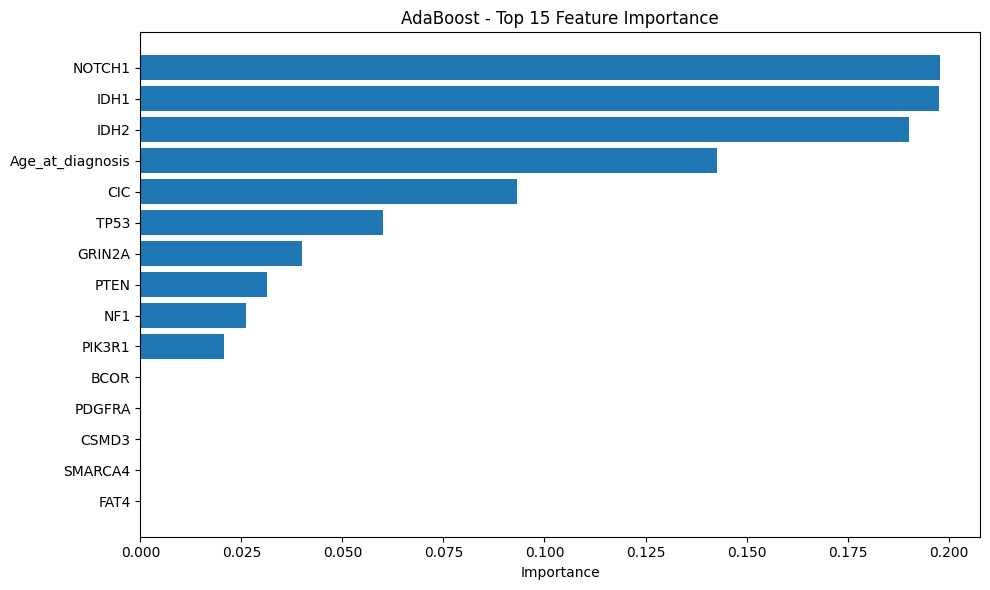

In [41]:
print("\n" + "="*60)
print("4. ADABOOST CLASSIFIER")
print("="*60)

ada_trainer = trainers['AdaBoost']

# Cross-validation
ada_cv_results = ada_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
ada_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on test and external sets
ada_eval_results = ada_trainer.evaluate(
    X_sets=[X_test_scaled, X_cgga_scaled],
    y_sets=[y_test, y_cgga],
    set_names=['Test', 'External (CGGA)']
)

# Plot confusion matrices
ada_trainer.plot_confusion_matrices()

# Feature importance
ada_importance = ada_trainer.get_feature_importance(feature_names)



5. EXTRATREES CLASSIFIER

Training ExtraTrees with 10-fold CV
  Fold 1: Accuracy = 0.8077, F1 = 0.8069
  Fold 2: Accuracy = 0.8718, F1 = 0.8717
  Fold 3: Accuracy = 0.8718, F1 = 0.8717
  Fold 4: Accuracy = 0.8205, F1 = 0.8205
  Fold 5: Accuracy = 0.8077, F1 = 0.8069
  Fold 6: Accuracy = 0.8205, F1 = 0.8205
  Fold 7: Accuracy = 0.8590, F1 = 0.8590
  Fold 8: Accuracy = 0.8846, F1 = 0.8846
  Fold 9: Accuracy = 0.8831, F1 = 0.8827
  Fold 10: Accuracy = 0.7792, F1 = 0.7792

CV Averages: Accuracy = 0.8406, Precision = 0.8426, Recall = 0.8406, F1 = 0.8404

Training final ExtraTrees model...
Training completed!

Evaluating ExtraTrees...


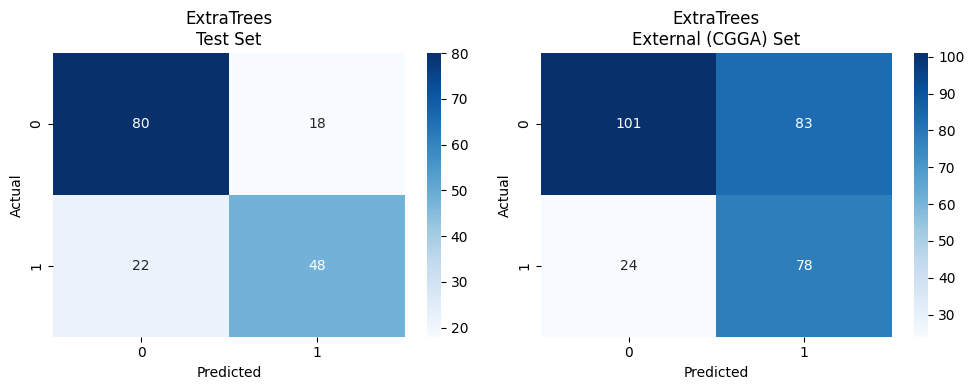

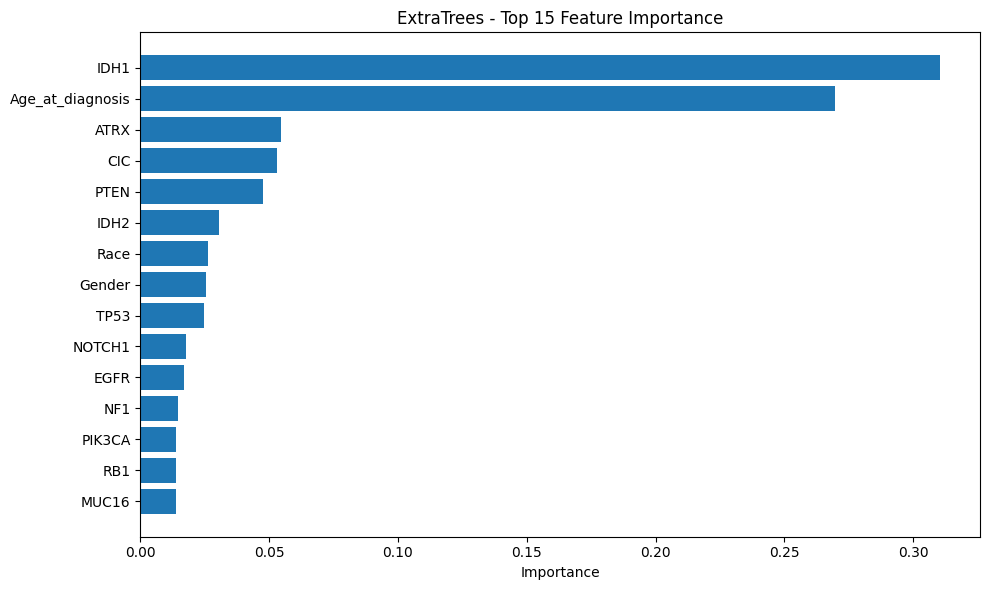

In [42]:
print("\n" + "="*60)
print("5. EXTRATREES CLASSIFIER")
print("="*60)

et_trainer = trainers['ExtraTrees']

# Cross-validation
et_cv_results = et_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
et_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on test and external sets
et_eval_results = et_trainer.evaluate(
    X_sets=[X_test_scaled, X_cgga_scaled],
    y_sets=[y_test, y_cgga],
    set_names=['Test', 'External (CGGA)']
)


# Plot confusion matrices
et_trainer.plot_confusion_matrices()

# Feature importance
et_importance = et_trainer.get_feature_importance(feature_names)




6. CATBOOST CLASSIFIER

Training CatBoost with 10-fold CV
  Fold 1: Accuracy = 0.8205, F1 = 0.8204
  Fold 2: Accuracy = 0.9359, F1 = 0.9358
  Fold 3: Accuracy = 0.8846, F1 = 0.8846
  Fold 4: Accuracy = 0.8590, F1 = 0.8590
  Fold 5: Accuracy = 0.8590, F1 = 0.8578
  Fold 6: Accuracy = 0.8974, F1 = 0.8968
  Fold 7: Accuracy = 0.8590, F1 = 0.8590
  Fold 8: Accuracy = 0.9615, F1 = 0.9615
  Fold 9: Accuracy = 0.8961, F1 = 0.8961
  Fold 10: Accuracy = 0.8182, F1 = 0.8176

CV Averages: Accuracy = 0.8791, Precision = 0.8824, Recall = 0.8791, F1 = 0.8788

Training final CatBoost model...
Training completed!

Evaluating CatBoost...


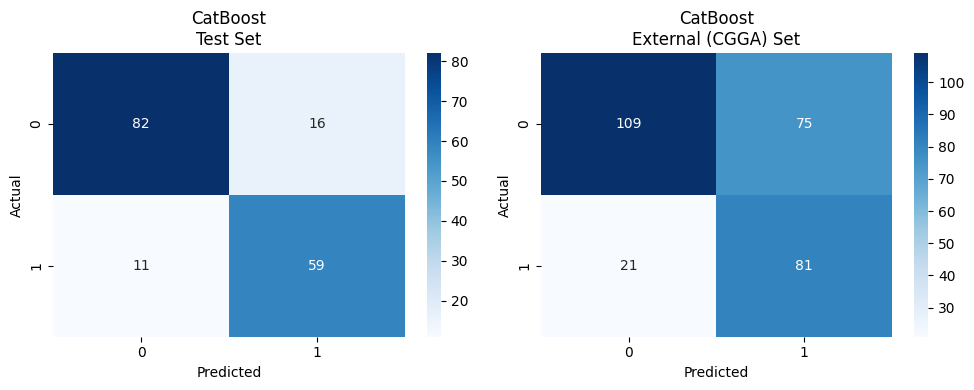

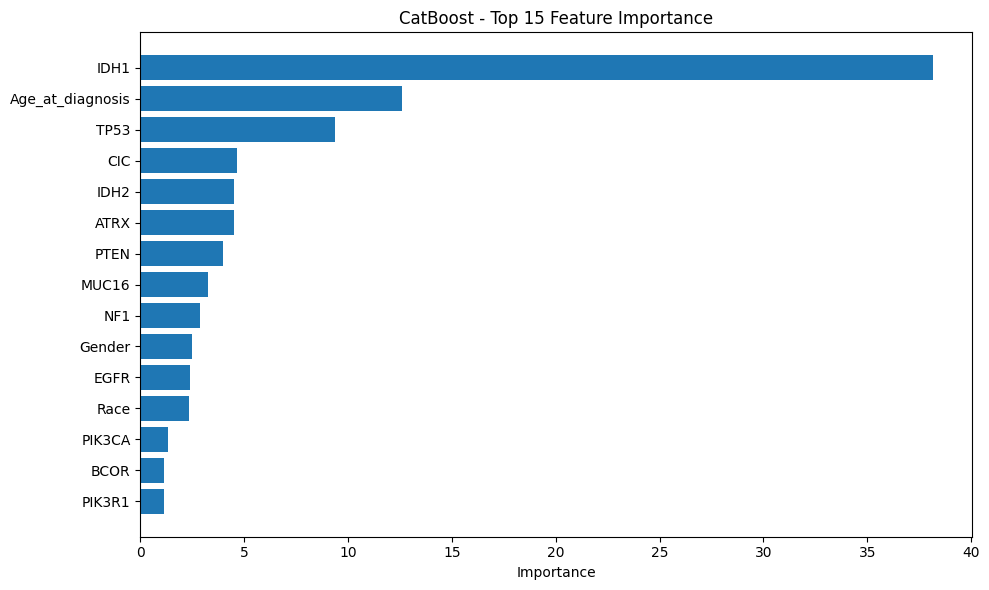

In [43]:
print("\n" + "="*60)
print("6. CATBOOST CLASSIFIER")
print("="*60)

cat_trainer = trainers['CatBoost']

# Cross-validation
cat_cv_results = cat_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
cat_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on test and external sets
cat_eval_results = cat_trainer.evaluate(
    X_sets=[X_test_scaled, X_cgga_scaled],
    y_sets=[y_test, y_cgga],
    set_names=['Test', 'External (CGGA)']
)


# Plot confusion matrices
cat_trainer.plot_confusion_matrices()

# Feature importance
cat_importance = cat_trainer.get_feature_importance(feature_names)



7. LIGHTGBM CLASSIFIER

Training LightGBM with 10-fold CV
  Fold 1: Accuracy = 0.7949, F1 = 0.7943
  Fold 2: Accuracy = 0.8718, F1 = 0.8718
  Fold 3: Accuracy = 0.8462, F1 = 0.8462
  Fold 4: Accuracy = 0.8205, F1 = 0.8200
  Fold 5: Accuracy = 0.8462, F1 = 0.8461
  Fold 6: Accuracy = 0.8718, F1 = 0.8715
  Fold 7: Accuracy = 0.8590, F1 = 0.8590
  Fold 8: Accuracy = 0.9103, F1 = 0.9102
  Fold 9: Accuracy = 0.8442, F1 = 0.8441
  Fold 10: Accuracy = 0.7532, F1 = 0.7527

CV Averages: Accuracy = 0.8418, Precision = 0.8432, Recall = 0.8418, F1 = 0.8416

Training final LightGBM model...
Training completed!

Evaluating LightGBM...


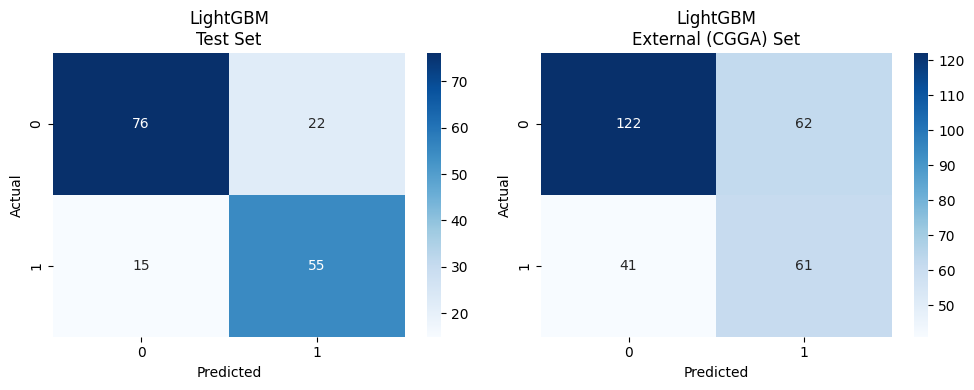

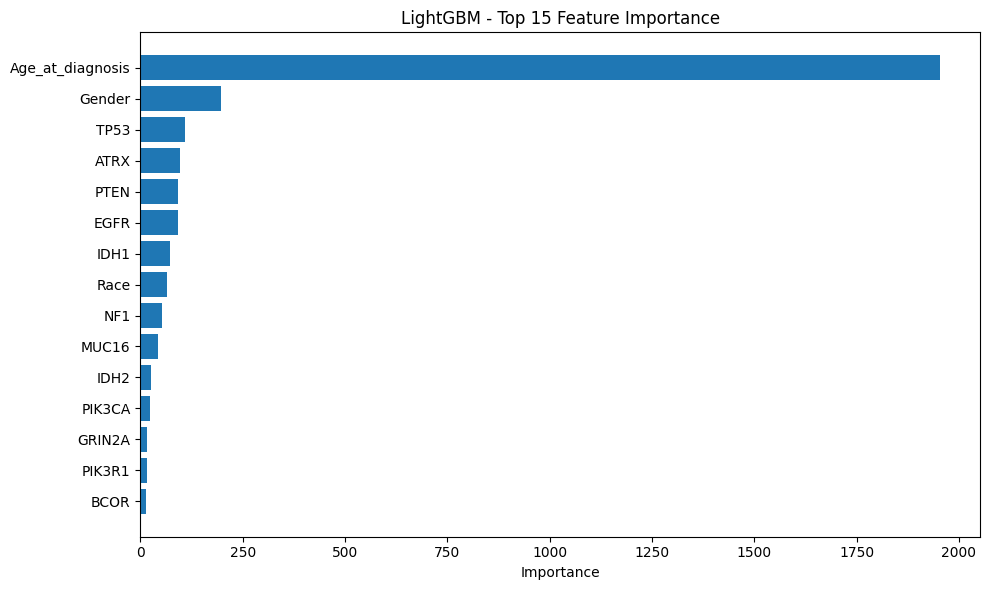

In [44]:
print("\n" + "="*60)
print("7. LIGHTGBM CLASSIFIER")
print("="*60)

lgb_trainer = trainers['LightGBM']

# Cross-validation
lgb_cv_results = lgb_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
lgb_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on test and external sets
lgb_eval_results = lgb_trainer.evaluate(
    X_sets=[X_test_scaled, X_cgga_scaled],
    y_sets=[y_test, y_cgga],
    set_names=['Test', 'External (CGGA)']
)

# Plot confusion matrices
lgb_trainer.plot_confusion_matrices()

# Feature importance
lgb_importance = lgb_trainer.get_feature_importance(feature_names)


8. RIDGE CLASSIFIER

Training RidgeClassifier with 10-fold CV
  Fold 1: Accuracy = 0.8205, F1 = 0.8204
  Fold 2: Accuracy = 0.9487, F1 = 0.9487
  Fold 3: Accuracy = 0.8590, F1 = 0.8588
  Fold 4: Accuracy = 0.8462, F1 = 0.8461
  Fold 5: Accuracy = 0.8462, F1 = 0.8445
  Fold 6: Accuracy = 0.9103, F1 = 0.9095
  Fold 7: Accuracy = 0.8205, F1 = 0.8200
  Fold 8: Accuracy = 0.9615, F1 = 0.9615
  Fold 9: Accuracy = 0.9091, F1 = 0.9090
  Fold 10: Accuracy = 0.8052, F1 = 0.8042

CV Averages: Accuracy = 0.8727, Precision = 0.8775, Recall = 0.8727, F1 = 0.8723

Training final RidgeClassifier model...
Training completed!

Evaluating RidgeClassifier...


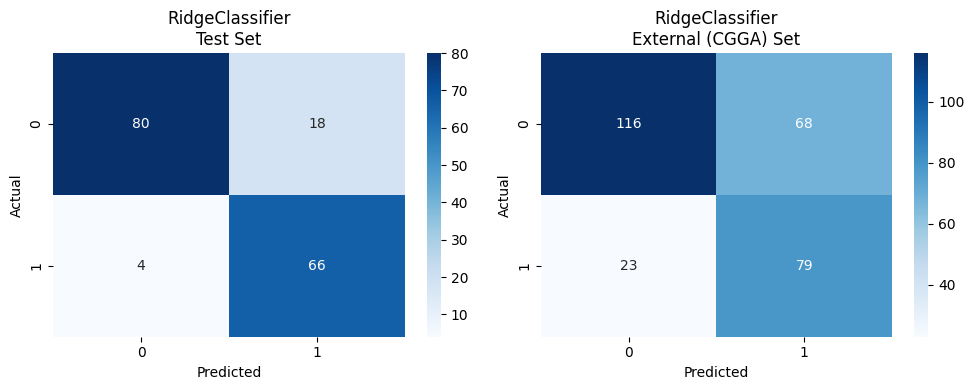

In [45]:
print("\n" + "="*60)
print("8. RIDGE CLASSIFIER")
print("="*60)

ridge_trainer = trainers['RidgeClassifier']

# Cross-validation
ridge_cv_results = ridge_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
ridge_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate on test and external sets
ridge_eval_results = ridge_trainer.evaluate(
    X_sets=[X_test_scaled, X_cgga_scaled],
    y_sets=[y_test, y_cgga],
    set_names=['Test', 'External (CGGA)']
)

# Plot confusion matrices
ridge_trainer.plot_confusion_matrices()


9. LASSO LOGISTIC REGRESSION

Training Lasso_Logistic with 10-fold CV
  Fold 1: Accuracy = 0.8205, F1 = 0.8204
  Fold 2: Accuracy = 0.9487, F1 = 0.9487
  Fold 3: Accuracy = 0.8718, F1 = 0.8717
  Fold 4: Accuracy = 0.8205, F1 = 0.8204
  Fold 5: Accuracy = 0.8718, F1 = 0.8704
  Fold 6: Accuracy = 0.9103, F1 = 0.9095
  Fold 7: Accuracy = 0.8333, F1 = 0.8331
  Fold 8: Accuracy = 0.9615, F1 = 0.9615
  Fold 9: Accuracy = 0.9091, F1 = 0.9090
  Fold 10: Accuracy = 0.8052, F1 = 0.8042

CV Averages: Accuracy = 0.8753, Precision = 0.8799, Recall = 0.8753, F1 = 0.8749

Training final Lasso_Logistic model...
Training completed!

Evaluating Lasso_Logistic...


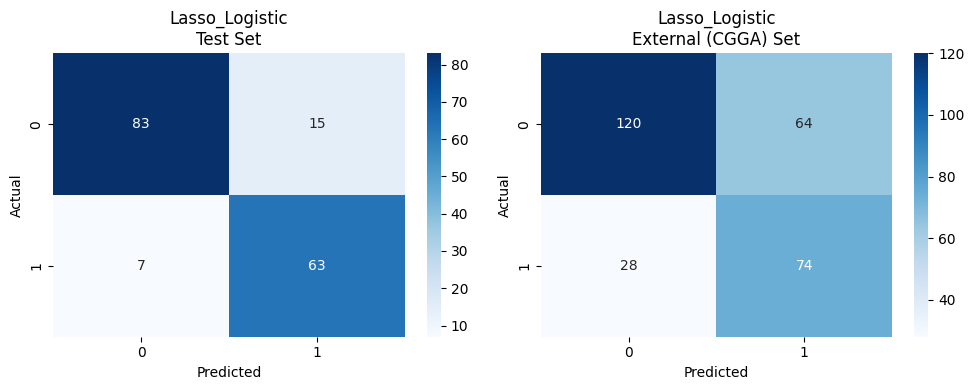

In [46]:
# Lasso  
print("\n" + "="*60)
print("9. LASSO LOGISTIC REGRESSION")
print("="*60)

lasso_trainer = trainers['Lasso_Logistic']

# Cross-validation
lasso_cv_results = lasso_trainer.train_with_cv(X_train_balanced, y_train_balanced, n_splits=10)

# Train final model
lasso_trainer.train_final(X_train_balanced, y_train_balanced)

# Evaluate
lasso_eval_results = lasso_trainer.evaluate(
    X_sets=[X_test_scaled, X_cgga_scaled],
    y_sets=[y_test, y_cgga],
    set_names=['Test', 'External (CGGA)']
)

# Plot confusion matrices
lasso_trainer.plot_confusion_matrices()

In [47]:
print("\n" + "="*80)
print("COMPARISON OF ALL MODELS")
print("="*80)

# Create comparison DataFrame
comparison_data = []

for model_name, trainer in trainers.items():
    if 'evaluation' in trainer.results:
        for dataset, scores in trainer.results['evaluation'].items():
            comparison_data.append({
                'Model': model_name,
                'Dataset': dataset,
                'Accuracy': scores['accuracy'],
                'Precision': scores['precision'],
                'Recall': scores['recall'],
                'F1': scores['f1'],
                'ROC_AUC': scores['roc_auc'] if scores['roc_auc'] else np.nan,
                'CV_F1_Avg': trainer.results['cv_avg']['f1'] if 'cv_avg' in trainer.results else np.nan
            })

comparison_df = pd.DataFrame(comparison_data)
print("\nPerformance Comparison:")
print("-" * 100)
for dataset in ['Test', 'External (CGGA)']:
    print(f"\n{dataset} Set Performance:")
    dataset_df = comparison_df[comparison_df['Dataset'] == dataset]
    print(dataset_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']]
          .sort_values('F1', ascending=False).to_string(index=False))
    print("-" * 100)


COMPARISON OF ALL MODELS

Performance Comparison:
----------------------------------------------------------------------------------------------------

Test Set Performance:
             Model  Accuracy  Precision   Recall       F1  ROC_AUC
          AdaBoost  0.869048   0.882937 0.869048 0.869963 0.920700
   RidgeClassifier  0.869048   0.882937 0.869048 0.869963 0.915889
    Lasso_Logistic  0.869048   0.874501 0.869048 0.869801 0.918367
LogisticRegression  0.869048   0.874501 0.869048 0.869801 0.917055
          CatBoost  0.839286   0.842115 0.839286 0.839953 0.917055
           XGBoost  0.809524   0.813406 0.809524 0.810430 0.901603
          LightGBM  0.779762   0.784799 0.779762 0.780927 0.901312
      RandomForest  0.779762   0.780250 0.779762 0.779978 0.884694
        ExtraTrees  0.761905   0.760547 0.761905 0.760784 0.853790
----------------------------------------------------------------------------------------------------

External (CGGA) Set Performance:
             Model  


VISUALIZATION OF RESULTS


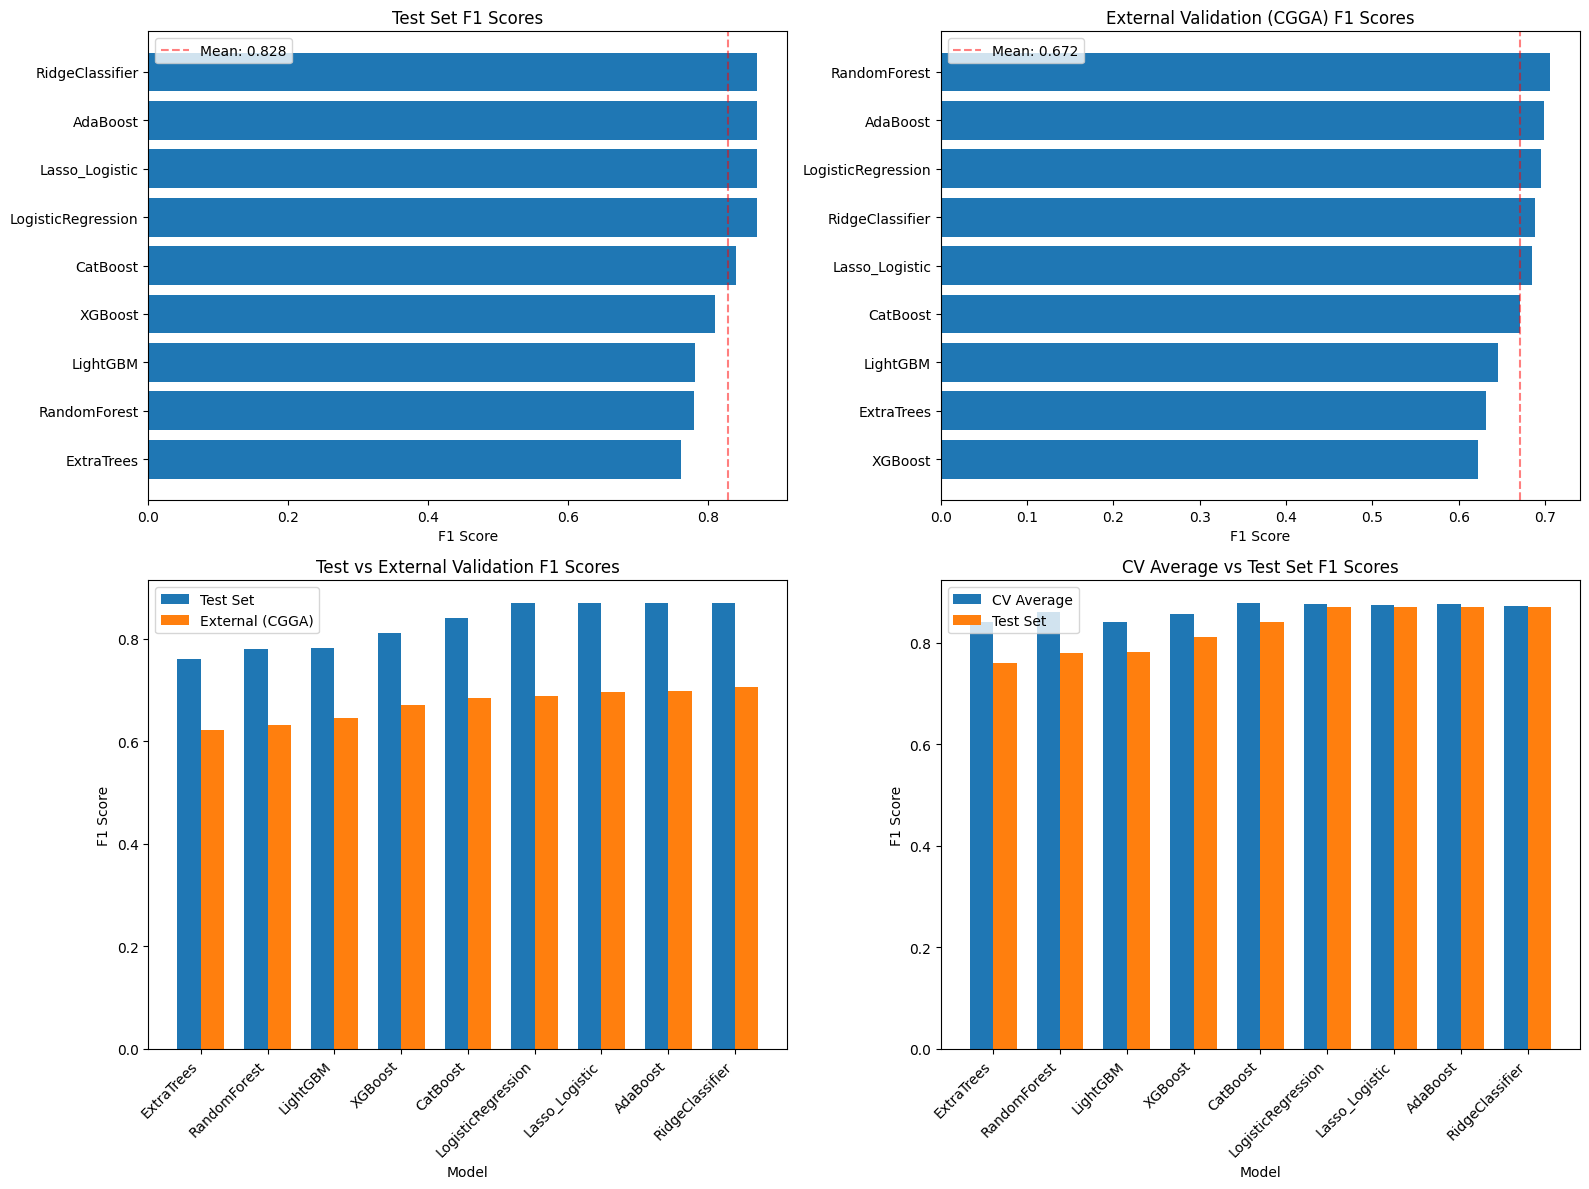

In [48]:
# Visualization of Results
print("\n" + "="*80)
print("VISUALIZATION OF RESULTS")
print("="*80)

# 1. Model comparison by F1 score
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test set F1 scores
test_f1 = comparison_df[comparison_df['Dataset'] == 'Test'].set_index('Model')['F1'].sort_values()
axes[0, 0].barh(test_f1.index, test_f1.values)
axes[0, 0].set_title('Test Set F1 Scores')
axes[0, 0].set_xlabel('F1 Score')
axes[0, 0].axvline(x=test_f1.mean(), color='r', linestyle='--', alpha=0.5, label=f'Mean: {test_f1.mean():.3f}')
axes[0, 0].legend()

# External validation F1 scores
ext_f1 = comparison_df[comparison_df['Dataset'] == 'External (CGGA)'].set_index('Model')['F1'].sort_values()
axes[0, 1].barh(ext_f1.index, ext_f1.values)
axes[0, 1].set_title('External Validation (CGGA) F1 Scores')
axes[0, 1].set_xlabel('F1 Score')
axes[0, 1].axvline(x=ext_f1.mean(), color='r', linestyle='--', alpha=0.5, label=f'Mean: {ext_f1.mean():.3f}')
axes[0, 1].legend()

# Test vs External F1 comparison
models = test_f1.index
x = np.arange(len(models))
width = 0.35
axes[1, 0].bar(x - width/2, test_f1.values, width, label='Test Set')
axes[1, 0].bar(x + width/2, ext_f1.values, width, label='External (CGGA)')
axes[1, 0].set_title('Test vs External Validation F1 Scores')
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
axes[1, 0].legend()

# CV vs Test F1 comparison
cv_vs_test = []
for model in models:
    cv_score = comparison_df[(comparison_df['Model'] == model) & 
                            (comparison_df['Dataset'] == 'Test')]['CV_F1_Avg'].values[0]
    test_score = comparison_df[(comparison_df['Model'] == model) & 
                              (comparison_df['Dataset'] == 'Test')]['F1'].values[0]
    cv_vs_test.append((cv_score, test_score))

cv_scores = [x[0] for x in cv_vs_test]
test_scores = [x[1] for x in cv_vs_test]

axes[1, 1].bar(x - width/2, cv_scores, width, label='CV Average')
axes[1, 1].bar(x + width/2, test_scores, width, label='Test Set')
axes[1, 1].set_title('CV Average vs Test Set F1 Scores')
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=45, ha='right')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


Performance Heatmap (Normalized):


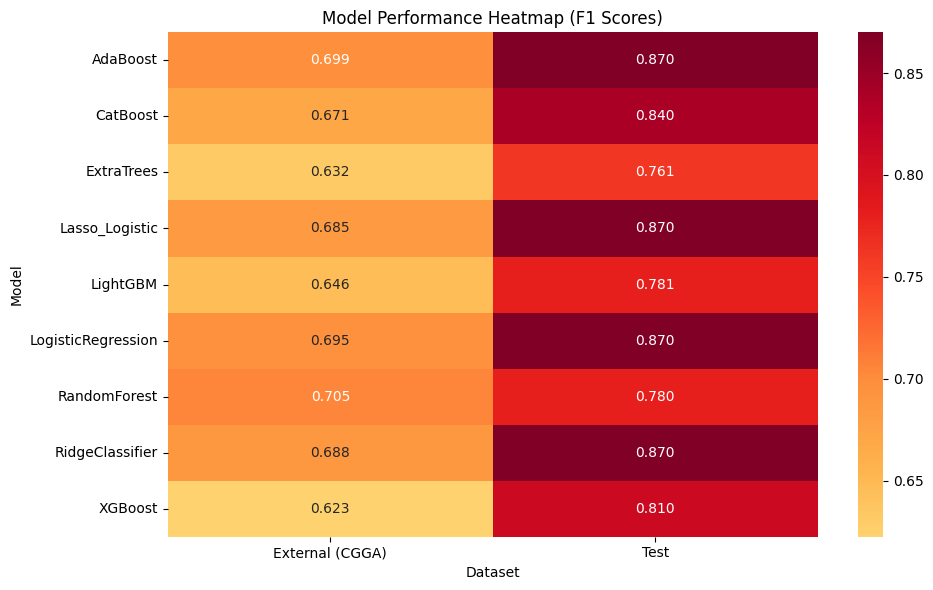

In [49]:
# 2. Performance summary heatmap
print("\nPerformance Heatmap (Normalized):")
# Create a normalized performance matrix
performance_matrix = pd.pivot_table(comparison_df, 
                                   values='F1', 
                                   index='Model', 
                                   columns='Dataset')

plt.figure(figsize=(10, 6))
sns.heatmap(performance_matrix, annot=True, fmt='.3f', cmap='YlOrRd', center=0.7)
plt.title('Model Performance Heatmap (F1 Scores)')
plt.tight_layout()
plt.show()

In [50]:
print("\n" + "="*80)
print("BEST MODELS ANALYSIS")
print("="*80)

# Find best model for each dataset
# We only have 'Test' and 'External (CGGA)' datasets now (no Validation set)
datasets = ['Test', 'External (CGGA)']
best_models = {}

for dataset in datasets:
    # Filter for the current dataset
    dataset_df = comparison_df[comparison_df['Dataset'] == dataset]
    
    # Check if dataset exists and has data
    if len(dataset_df) > 0:
        best_model = dataset_df.loc[dataset_df['F1'].idxmax()]
        best_models[dataset] = best_model
        print(f"\nBest model for {dataset}:")
        print(f"  Model: {best_model['Model']}")
        print(f"  F1 Score: {best_model['F1']:.4f}")
        print(f"  Accuracy: {best_model['Accuracy']:.4f}")
        print(f"  CV F1 Average: {best_model['CV_F1_Avg']:.4f}")
    else:
        print(f"\nNo data available for {dataset} dataset")

# Find most consistent model (best average across all datasets)
if len(comparison_df) > 0:
    model_avg_f1 = comparison_df.groupby('Model')['F1'].mean().sort_values(ascending=False)
    print(f"\n\nMost consistent model (average F1 across all datasets):")
    print(f"  Model: {model_avg_f1.index[0]}")
    print(f"  Average F1: {model_avg_f1.values[0]:.4f}")
else:
    print("\nNo comparison data available")

# Check for overfitting
print("\n\nOverfitting Analysis:")
print("-" * 60)

# Get unique models that have Test set results
test_models = comparison_df[comparison_df['Dataset'] == 'Test']['Model'].unique()

for model in test_models:
    # Get data for this model on Test set
    model_test_data = comparison_df[(comparison_df['Model'] == model) & 
                                   (comparison_df['Dataset'] == 'Test')]
    
    if len(model_test_data) > 0:
        cv_f1 = model_test_data['CV_F1_Avg'].values[0]
        test_f1 = model_test_data['F1'].values[0]
        
        diff = cv_f1 - test_f1
        if diff > 0.15:
            status = "HIGH OVERFITTING"
        elif diff > 0.05:
            status = "Moderate overfitting"
        elif diff < -0.05:
            status = "Underfitting"
        else:
            status = "✓ Good generalization"
        
        print(f"{model:20} CV F1: {cv_f1:.4f}, Test F1: {test_f1:.4f}, Diff: {diff:.4f} - {status}")
    else:
        print(f"{model:20} - No test data available")



BEST MODELS ANALYSIS

Best model for Test:
  Model: AdaBoost
  F1 Score: 0.8700
  Accuracy: 0.8690
  CV F1 Average: 0.8761

Best model for External (CGGA):
  Model: RandomForest
  F1 Score: 0.7054
  Accuracy: 0.6993
  CV F1 Average: 0.8596


Most consistent model (average F1 across all datasets):
  Model: AdaBoost
  Average F1: 0.7844


Overfitting Analysis:
------------------------------------------------------------
RandomForest         CV F1: 0.8596, Test F1: 0.7800, Diff: 0.0796 - Moderate overfitting
LogisticRegression   CV F1: 0.8761, Test F1: 0.8698, Diff: 0.0063 - ✓ Good generalization
XGBoost              CV F1: 0.8569, Test F1: 0.8104, Diff: 0.0464 - ✓ Good generalization
AdaBoost             CV F1: 0.8761, Test F1: 0.8700, Diff: 0.0061 - ✓ Good generalization
ExtraTrees           CV F1: 0.8404, Test F1: 0.7608, Diff: 0.0796 - Moderate overfitting
CatBoost             CV F1: 0.8788, Test F1: 0.8400, Diff: 0.0389 - ✓ Good generalization
LightGBM             CV F1: 0.8416, Tes

In [51]:
# Add generalization analysis (Test vs External)
print("\n\nGeneralization Analysis (Test vs External):")
print("-" * 60)

for model in test_models:
    # Get Test set performance
    test_data = comparison_df[(comparison_df['Model'] == model) & 
                             (comparison_df['Dataset'] == 'Test')]
    
    # Get External set performance
    ext_data = comparison_df[(comparison_df['Model'] == model) & 
                            (comparison_df['Dataset'] == 'External (CGGA)')]
    
    if len(test_data) > 0 and len(ext_data) > 0:
        test_f1 = test_data['F1'].values[0]
        ext_f1 = ext_data['F1'].values[0]
        
        diff = test_f1 - ext_f1
        if diff > 0.2:
            status = "POOR GENERALIZATION"
        elif diff > 0.1:
            status = "Moderate generalization issue"
        elif diff < -0.1:
            status = "Better on external data"
        else:
            status = "✓ Good generalization"
        
        print(f"{model:20} Test F1: {test_f1:.4f}, External F1: {ext_f1:.4f}, Diff: {diff:.4f} - {status}")
    else:
        print(f"{model:20} - Missing performance data")




Generalization Analysis (Test vs External):
------------------------------------------------------------
RandomForest         Test F1: 0.7800, External F1: 0.7054, Diff: 0.0746 - ✓ Good generalization
LogisticRegression   Test F1: 0.8698, External F1: 0.6952, Diff: 0.1746 - Moderate generalization issue
XGBoost              Test F1: 0.8104, External F1: 0.6225, Diff: 0.1879 - Moderate generalization issue
AdaBoost             Test F1: 0.8700, External F1: 0.6987, Diff: 0.1712 - Moderate generalization issue
ExtraTrees           Test F1: 0.7608, External F1: 0.6321, Diff: 0.1287 - Moderate generalization issue
CatBoost             Test F1: 0.8400, External F1: 0.6706, Diff: 0.1694 - Moderate generalization issue
LightGBM             Test F1: 0.7809, External F1: 0.6458, Diff: 0.1352 - Moderate generalization issue
RidgeClassifier      Test F1: 0.8700, External F1: 0.6884, Diff: 0.1816 - Moderate generalization issue
Lasso_Logistic       Test F1: 0.8698, External F1: 0.6850, Diff: 0.18

In [52]:
# NEW: Separate section to create good_gen_models and display summary
print("\n" + "="*60)
print("GENERALIZATION SUMMARY")
print("="*60)


GENERALIZATION SUMMARY


In [53]:
# Create good_gen_models list
good_gen_models = []

for model in test_models:
    test_data = comparison_df[(comparison_df['Model'] == model) & 
                             (comparison_df['Dataset'] == 'Test')]
    ext_data = comparison_df[(comparison_df['Model'] == model) & 
                            (comparison_df['Dataset'] == 'External (CGGA)')]
    
    if len(test_data) > 0 and len(ext_data) > 0:
        test_f1 = test_data['F1'].values[0]
        ext_f1 = ext_data['F1'].values[0]
        diff = abs(test_f1 - ext_f1)
        
        if diff < 0.1:  # Less than 10% difference
            good_gen_models.append((model, diff, (test_f1 + ext_f1)/2))

# Display summary
if good_gen_models:
    print(f"\n Found {len(good_gen_models)} model(s) with good generalization (<10% difference):")
    print("-" * 60)
    
    # Sort by average F1 (highest first)
    good_gen_models.sort(key=lambda x: x[2], reverse=True)
    
    for model, diff, avg_f1 in good_gen_models:
        print(f"✓ {model:20} | Diff: {diff:.4f} | Avg F1: {avg_f1:.4f}")
else:
    print("\n No models show excellent generalization (<10% difference)")


 Found 1 model(s) with good generalization (<10% difference):
------------------------------------------------------------
✓ RandomForest         | Diff: 0.0746 | Avg F1: 0.7427


In [54]:
# Find overall best model based on average performance
if len(best_models) > 0:
    print("\nOverall Recommendations:")
    print("-" * 40)
    
    # If the same model is best for both Test and External
    if len(set([bm['Model'] for bm in best_models.values()])) == 1:
        overall_best = list(best_models.values())[0]['Model']
        print(f"✓ {overall_best} is the best model for both internal and external validation")
    else:
        test_best = best_models['Test']['Model']
        ext_best = best_models['External (CGGA)']['Model']
        print(f"✓ Best for internal validation (Test): {test_best}")
        print(f"✓ Best for external validation (CGGA): {ext_best}")
        
        # Check if they're close
        test_f1 = best_models['Test']['F1']
        ext_f1 = best_models['External (CGGA)']['F1']
        if abs(test_f1 - ext_f1) < 0.1:
            print(f"✓ Both models perform similarly (difference: {abs(test_f1 - ext_f1):.3f})")


Overall Recommendations:
----------------------------------------
✓ Best for internal validation (Test): AdaBoost
✓ Best for external validation (CGGA): RandomForest


In [55]:
# Check for models with good generalization
print("\nModels with Good Generalization:")
print("-" * 40)
if good_gen_models:
    for model, diff, avg_f1 in good_gen_models:
        print(f"✓ {model}: Difference = {diff:.3f}, Average F1 = {avg_f1:.3f}")
else:
    print("No models show excellent generalization (<10% difference)")


Models with Good Generalization:
----------------------------------------
✓ RandomForest: Difference = 0.075, Average F1 = 0.743


In [56]:
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Define constants
DATASETS = ['Test', 'External (CGGA)']
METRICS = ['accuracy', 'precision', 'recall', 'f1']

try:
    # Save comparison DataFrame
    comparison_df.to_csv('all_models_comparison.csv', index=False)
    print("Comparison results saved to 'all_models_comparison.csv'")
    
    # Save detailed results for each model
    for model_name, trainer in trainers.items():
        if not trainer.results:
            print(f"⚠ No results for {model_name}, skipping...")
            continue
            
        try:
            # Build metrics dataframe programmatically
            metric_rows = []
            values = []
            
            # CV metrics
            cv_metrics = ['CV_Avg_Accuracy', 'CV_Avg_Precision', 'CV_Avg_Recall', 'CV_Avg_F1']
            for metric_name, metric_key in zip(cv_metrics, METRICS):
                metric_rows.append(metric_name)
                values.append(trainer.results.get('cv_avg', {}).get(metric_key, None))
            
            # Test/External metrics
            for dataset in DATASETS:
                dataset_results = trainer.results.get('evaluation', {}).get(dataset, {})
                for metric in METRICS:
                    metric_rows.append(f'{dataset}_{metric.capitalize()}')
                    values.append(dataset_results.get(metric, None))
            
            # Create and save DataFrame
            model_results = pd.DataFrame({
                'Metric': metric_rows,
                'Value': values
            })
            
            filename = f'{model_name}_results.csv'
            model_results.to_csv(filename, index=False)
            print(f"✓ {model_name} results saved to '{filename}'")
            
        except Exception as e:
            print(f"✗ Error saving {model_name} results: {e}")
            continue
    
    print("\nDetailed model results saved as CSV files.")
    
    # Save best models summary
    if best_models:
        try:
            best_models_summary = []
            for dataset, best_model in best_models.items():
                best_models_summary.append({
                    'Dataset': dataset,
                    'Best_Model': best_model.get('Model', 'Unknown'),
                    'F1_Score': best_model.get('F1', None),
                    'Accuracy': best_model.get('Accuracy', None),
                    'CV_F1_Avg': best_model.get('CV_F1_Avg', None)
                })
            
            best_models_df = pd.DataFrame(best_models_summary)
            best_models_df.to_csv('best_models_summary.csv', index=False)
            print("Best models summary saved to 'best_models_summary.csv'")
            
        except Exception as e:
            print(f"✗ Error saving best models summary: {e}")
    
    # Generate recommendations
    print("\n" + "="*80)
    print("OVERALL RECOMMENDATIONS")
    print("="*80)
    
    if best_models:
        print("\nOverall Recommendations:")
        print("-" * 40)
        
        # Get unique best models
        best_model_names = {dataset: info.get('Model') for dataset, info in best_models.items()}
        unique_models = set(best_model_names.values())
        
        if len(unique_models) == 1:
            overall_best = next(iter(unique_models))
            print(f"✓ {overall_best} is the best model for both internal and external validation")
        else:
            for dataset in DATASETS:
                if dataset in best_model_names:
                    model_name = best_model_names[dataset]
                    f1_score = best_models[dataset].get('F1', 'N/A')
                    print(f"✓ Best for {dataset}: {model_name} (F1: {f1_score:.3f})")
            
            # Compare performance if both datasets present
            if all(ds in best_models for ds in ['Test', 'External (CGGA)']):
                test_f1 = best_models['Test'].get('F1', 0)
                ext_f1 = best_models['External (CGGA)'].get('F1', 0)
                
                if isinstance(test_f1, (int, float)) and isinstance(ext_f1, (int, float)):
                    diff = abs(test_f1 - ext_f1)
                    if diff < 0.1:
                        print(f"✓ Performance difference is small ({diff:.3f})")
                    else:
                        print(f"⚠ Note: Performance difference is significant ({diff:.3f})")

except Exception as e:
    print(f"✗ Critical error in save/recommendation phase: {e}")


SAVING RESULTS
Comparison results saved to 'all_models_comparison.csv'
✓ RandomForest results saved to 'RandomForest_results.csv'
✓ LogisticRegression results saved to 'LogisticRegression_results.csv'
✓ XGBoost results saved to 'XGBoost_results.csv'
✓ AdaBoost results saved to 'AdaBoost_results.csv'
✓ ExtraTrees results saved to 'ExtraTrees_results.csv'
✓ CatBoost results saved to 'CatBoost_results.csv'
✓ LightGBM results saved to 'LightGBM_results.csv'
✓ RidgeClassifier results saved to 'RidgeClassifier_results.csv'
✓ Lasso_Logistic results saved to 'Lasso_Logistic_results.csv'

Detailed model results saved as CSV files.
Best models summary saved to 'best_models_summary.csv'

OVERALL RECOMMENDATIONS

Overall Recommendations:
----------------------------------------
✓ Best for Test: AdaBoost (F1: 0.870)
✓ Best for External (CGGA): RandomForest (F1: 0.705)
⚠ Note: Performance difference is significant (0.165)
